In [1]:
!pip install kaggle

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets download -d omkargurav/face-mask-dataset

Dataset URL: https://www.kaggle.com/datasets/omkargurav/face-mask-dataset
License(s): unknown
face-mask-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
import os
os.listdir()


['.config', 'face-mask-dataset.zip', 'kaggle.json', 'sample_data']

In [9]:
from zipfile import ZipFile
dataset = '/content/face-mask-dataset.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

In [11]:
with_mask = os.listdir("/content/face-mask-dataset/data/with_mask")
without_mask = os.listdir("/content/face-mask-dataset/data/without_mask")

In [12]:
len(with_mask), len(without_mask)

(3725, 3828)

**creating labels for data - its a binary problem so that give only 0, 1 for the mask and without mask**

In [16]:
with_mask_labels = [1]*len(with_mask)
without_mask_labels = [0]*len(without_mask)

In [17]:
print(with_mask_labels[0:5])

[1, 1, 1, 1, 1]


In [18]:
len(with_mask_labels), len(without_mask_labels)

(3725, 3828)

In [27]:
labels = with_mask_labels + without_mask_labels

visualize image daimention


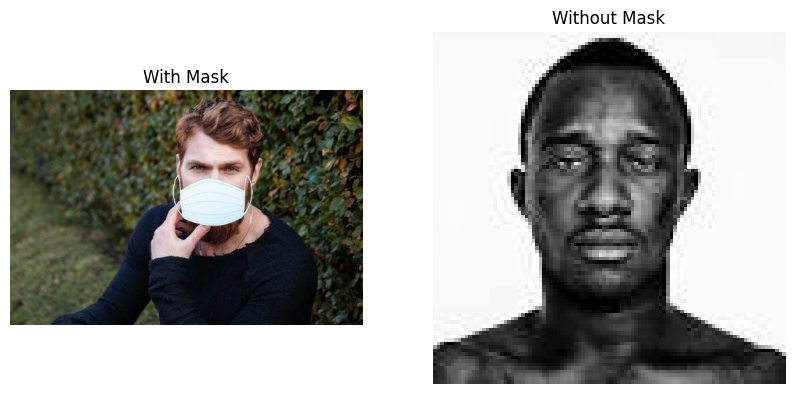

In [20]:
img1 = mpimg.imread('/content/data/with_mask/with_mask_1.jpg')
img2 = mpimg.imread('/content/data/without_mask/without_mask_1.jpg')

plt.figure(figsize=(10, 5))

# First image
plt.subplot(1, 2, 1)
plt.imshow(img1)
plt.title("With Mask")
plt.axis('off')

# Second image
plt.subplot(1, 2, 2)
plt.imshow(img2)
plt.title("Without Mask")
plt.axis('off')

plt.show()


These two images differ in size, so it is essential to resize them for consistent processing

In [22]:
with_mask_path = "/content/face-mask-dataset/data/with_mask/"

data = []

for i in with_mask:
  image = Image.open(with_mask_path + i)
  image = image.resize((128,128))
  image = image.convert('RGB') # the second image in black in white
  image = np.array(image)
  data.append(image)


without_mask_path = "/content/face-mask-dataset/data/without_mask/"

for i in without_mask:
  image = Image.open(without_mask_path + i)
  image = image.resize((128,128))
  image = image.convert('RGB') # the second image in black in white
  image = np.array(image)
  data.append(image)

In [26]:
# type(data)
type(data[0])
data[0].shape

(128, 128, 3)

now convert list into np arrays and combine data and labels

In [28]:
x = np.array(data)
y = np.array(labels)

In [29]:
print(x.shape, y.shape)

(7553, 128, 128, 3) (7553,)


In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [33]:
print(x_train[0])

[[[ 23  22  28]
  [ 22  21  27]
  [ 20  19  25]
  ...
  [122  85  52]
  [126  97  66]
  [151 131 108]]

 [[ 23  22  28]
  [ 21  20  26]
  [ 20  19  25]
  ...
  [119  82  50]
  [135 106  77]
  [187 167 144]]

 [[ 22  21  27]
  [ 21  20  26]
  [ 18  17  23]
  ...
  [116  79  49]
  [131 102  73]
  [176 156 134]]

 ...

 [[  4   4   4]
  [  5   5   5]
  [  6   6   6]
  ...
  [ 35  54  86]
  [ 27  46  79]
  [ 26  44  79]]

 [[  4   4   4]
  [  5   5   5]
  [  6   6   6]
  ...
  [ 30  48  83]
  [ 20  38  75]
  [ 20  38  77]]

 [[  4   4   4]
  [  5   5   5]
  [  6   6   6]
  ...
  [ 26  44  82]
  [ 16  34  72]
  [ 17  35  76]]]


In [34]:
x_train_sc = x_train/255
x_test_sc = x_test/255

In [35]:
import tensorflow as tf
from tensorflow import keras

In [36]:
num_of_classes = 2

model = keras.Sequential()

model.add(keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(128,128,3)))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))


model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(keras.layers.MaxPooling2D(pool_size=(2,2)))

model.add(keras.layers.Flatten())

model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dropout(0.5))

model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dropout(0.5))


model.add(keras.layers.Dense(num_of_classes, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [37]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [38]:
hist = model.fit(x_train_sc,y_train, epochs=10, validation_data=(x_test_sc, y_test))

Epoch 1/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7045 - loss: 0.5377 - val_accuracy: 0.8570 - val_loss: 0.3316
Epoch 2/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.8895 - loss: 0.2932 - val_accuracy: 0.8098 - val_loss: 0.3686
Epoch 3/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9113 - loss: 0.2366 - val_accuracy: 0.9325 - val_loss: 0.1732
Epoch 4/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9407 - loss: 0.1799 - val_accuracy: 0.9470 - val_loss: 0.1448
Epoch 5/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9450 - loss: 0.1468 - val_accuracy: 0.9537 - val_loss: 0.1329
Epoch 6/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9567 - loss: 0.1227 - val_accuracy: 0.9594 - val_loss: 0.1380
Epoch 7/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9572 - loss: 0.1331 - val_accuracy: 0.9510 - val_loss: 0.1482
Epoch 8/10
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9632 - loss: 0.1047 - val_ac

Path of the image to be predicted: /content/download.jpeg


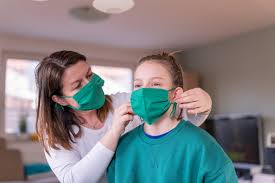

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step
[[0.14336975 0.8526161 ]]
1
The person in the image is wearing a mask


In [41]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resized = cv2.resize(input_image, (128,128))

input_image_scaled = input_image_resized/255

input_image_reshaped = np.reshape(input_image_scaled, [1,128,128,3])

input_prediction = model.predict(input_image_reshaped)

print(input_prediction)


input_pred_label = np.argmax(input_prediction)

print(input_pred_label)


if input_pred_label == 1:

  print('The person in the image is wearing a mask')

else:

  print('The person in the image is not wearing a mask')